<a href="https://colab.research.google.com/github/trblnyx/curso-2026-1/blob/trblnyx/notebooks/001_importando_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
import os
os.listdir('/content/drive/MyDrive/Colab Notebooks/data')


['006_Cuernavaca_1dia_comas_Nans.csv',
 '002_Cuernavca_To_1dia_tabulador.csv',
 '001_Cuernavaca_To_1dia_comas.csv',
 '004_Cuernavaca_To_1dia_comas.xlsx',
 '003_Cuernavaca_estacion_1dia_comas.csv',
 '005_Cuernavaca_1dia_comas_Encoding.txt',
 '007_Cuernavaca_1dia_comas_Nans.csv',
 'enerhabitat-meanday-2025-09-22.csv']

In [6]:
import pandas as pd
import matplotlib.pyplot as plt


In [14]:
f = "/content/drive/MyDrive/Colab Notebooks/data/enerhabitat-meanday-2025-09-22.csv"
cvj = pd.read_csv(f,index_col=0)
cvj.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86341 entries, 2025-04-15 00:00:00-06:00 to 2025-04-15 23:59:00-06:00
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   zenith            86341 non-null  float64
 1   elevation         86341 non-null  float64
 2   azimuth           86341 non-null  float64
 3   equation_of_time  86341 non-null  float64
 4   Ta                86341 non-null  float64
 5   Ig                86341 non-null  float64
 6   Ib                86341 non-null  float64
 7   Id                86341 non-null  float64
 8   Tn                86341 non-null  float64
 9   DeltaTn           86341 non-null  float64
dtypes: float64(10)
memory usage: 7.2+ MB


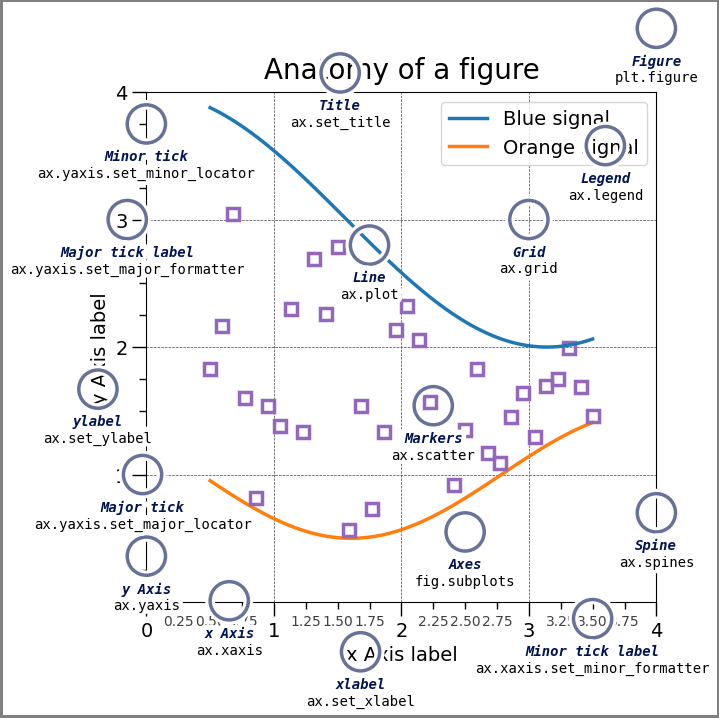

In [8]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import Circle
from matplotlib.patheffects import withStroke
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

royal_blue = [0, 20/256, 82/256]


# make the figure

np.random.seed(19680801)

X = np.linspace(0.5, 3.5, 100)
Y1 = 3+np.cos(X)
Y2 = 1+np.cos(1+X/0.75)/2
Y3 = np.random.uniform(Y1, Y2, len(X))

fig = plt.figure(figsize=(7.5, 7.5))
ax = fig.add_axes([0.2, 0.17, 0.68, 0.7], aspect=1)

ax.xaxis.set_major_locator(MultipleLocator(1.000))
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_major_locator(MultipleLocator(1.000))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.xaxis.set_minor_formatter("{x:.2f}")

ax.set_xlim(0, 4)
ax.set_ylim(0, 4)

ax.tick_params(which='major', width=1.0, length=10, labelsize=14)
ax.tick_params(which='minor', width=1.0, length=5, labelsize=10,
               labelcolor='0.25')

ax.grid(linestyle="--", linewidth=0.5, color='.25', zorder=-10)

ax.plot(X, Y1, c='C0', lw=2.5, label="Blue signal", zorder=10)
ax.plot(X, Y2, c='C1', lw=2.5, label="Orange signal")
ax.plot(X[::3], Y3[::3], linewidth=0, markersize=9,
        marker='s', markerfacecolor='none', markeredgecolor='C4',
        markeredgewidth=2.5)

ax.set_title("Anatomy of a figure", fontsize=20, verticalalignment='bottom')
ax.set_xlabel("x Axis label", fontsize=14)
ax.set_ylabel("y Axis label", fontsize=14)
ax.legend(loc="upper right", fontsize=14)


# Annotate the figure

def annotate(x, y, text, code):
    # Circle marker
    c = Circle((x, y), radius=0.15, clip_on=False, zorder=10, linewidth=2.5,
               edgecolor=royal_blue + [0.6], facecolor='none',
               path_effects=[withStroke(linewidth=7, foreground='white')])
    ax.add_artist(c)

    # use path_effects as a background for the texts
    # draw the path_effects and the colored text separately so that the
    # path_effects cannot clip other texts
    for path_effects in [[withStroke(linewidth=7, foreground='white')], []]:
        color = 'white' if path_effects else royal_blue
        ax.text(x, y-0.2, text, zorder=100,
                ha='center', va='top', weight='bold', color=color,
                style='italic', fontfamily='monospace',
                path_effects=path_effects)

        color = 'white' if path_effects else 'black'
        ax.text(x, y-0.33, code, zorder=100,
                ha='center', va='top', weight='normal', color=color,
                fontfamily='monospace', fontsize='medium',
                path_effects=path_effects)


annotate(3.5, -0.13, "Minor tick label", "ax.xaxis.set_minor_formatter")
annotate(-0.03, 1.0, "Major tick", "ax.yaxis.set_major_locator")
annotate(0.00, 3.75, "Minor tick", "ax.yaxis.set_minor_locator")
annotate(-0.15, 3.00, "Major tick label", "ax.yaxis.set_major_formatter")
annotate(1.68, -0.39, "xlabel", "ax.set_xlabel")
annotate(-0.38, 1.67, "ylabel", "ax.set_ylabel")
annotate(1.52, 4.15, "Title", "ax.set_title")
annotate(1.75, 2.80, "Line", "ax.plot")
annotate(2.25, 1.54, "Markers", "ax.scatter")
annotate(3.00, 3.00, "Grid", "ax.grid")
annotate(3.60, 3.58, "Legend", "ax.legend")
annotate(2.5, 0.55, "Axes", "fig.subplots")
annotate(4, 4.5, "Figure", "plt.figure")
annotate(0.65, 0.01, "x Axis", "ax.xaxis")
annotate(0, 0.36, "y Axis", "ax.yaxis")
annotate(4.0, 0.7, "Spine", "ax.spines")

# frame around figure
fig.patch.set(linewidth=4, edgecolor='0.5')
plt.show()

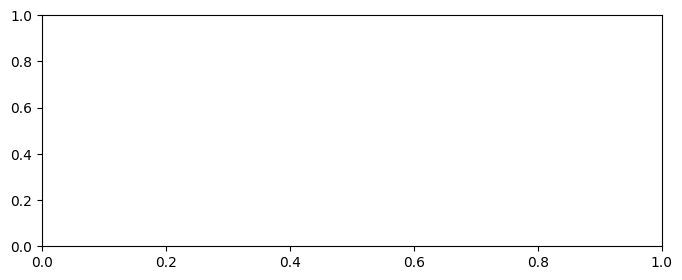

In [10]:
fix, ax = plt.subplots(figsize=(8,3))

In [20]:
ax.plot(cvj.Ta,label="Ta")
ax.plot(cvj.Tn + cvj.DeltaTn, label="Tn+")
ax.plot(cvj.Tn - cvj.DeltaTn, label="Tn-")
ax.legend()

In [21]:
plt.show()

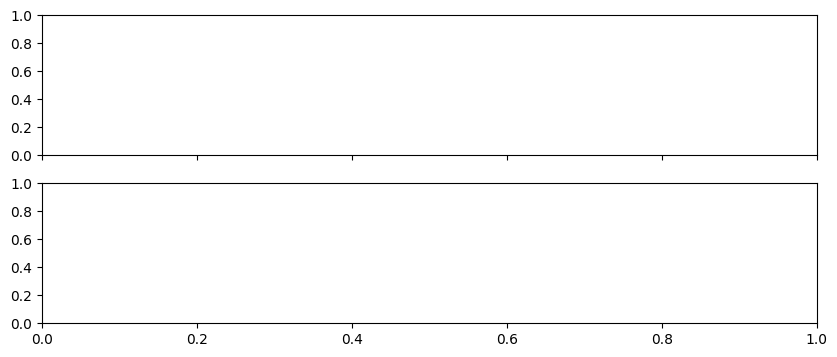

In [24]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(10,4),sharex=True)

In [26]:
ax1.plot(cvj.Ta,label="Ta")
ax2.plot(cvj.Ib,label="Ib")
ax2.plot(cvj.Id,label="Id")
ax2.plot(cvj.Ig,label="Ig")

In [29]:
ax1.legend()
ax2.legend()


In [31]:
plt.show()